In [13]:
import pandas as pd
import numpy as np

# Load the Excel file
df = pd.read_excel("C:/Users/User/Desktop/input_OR.xlsx")

# Convert log(1 + outage) back to outage
df["outage"] = np.exp(df["Value"]) - 1

# Compute average outage per county
avg_outage = df.groupby("Location")["outage"].mean().reset_index()

# Rename column
avg_outage = avg_outage.rename(columns={"outage": "avg_outage"})

# Print result
print(avg_outage)

# Optional: save result
avg_outage.to_csv("avg_outage_by_county.csv", index=False)

    Location  avg_outage
0      26001    1.007392
1      26003    0.147412
2      26005    2.263636
3      26007   -0.061829
4      26009    0.435198
..       ...         ...
78     26157   12.039770
79     26159    6.772607
80     26161   86.203036
81     26163  153.373782
82     26165    0.437946

[83 rows x 2 columns]


In [14]:
"""
Capacitated Weighted K-Means for Power Station Placement
=========================================================
Uses average outage data by Michigan county (FIPS) as weights.

Rules:
1. Each station capacity ≤ 1000 demand units
2. 5 stations total
3. Counties with demand > 1000 are ignored
4. Output shows which counties were ignored
"""

import numpy as np
import pandas as pd


# ── Michigan county coordinates ─────────────────────────────
MICHIGAN_COORDS = {
    26001:(44.738,-83.293),26003:(46.595,-86.495),26005:(42.578,-85.906),
    26007:(45.080,-83.430),26009:(44.997,-85.179),26011:(44.028,-83.737),
    26013:(46.797,-88.470),26015:(42.603,-85.305),26017:(43.684,-83.969),
    26019:(44.630,-86.046),26021:(41.922,-86.429),26023:(41.891,-85.056),
    26025:(42.244,-85.006),26027:(41.917,-85.990),26029:(45.380,-85.230),
    26031:(45.622,-84.474),26033:(46.360,-84.460),26035:(43.983,-84.841),
    26037:(42.947,-84.597),26039:(44.683,-84.607),26041:(45.787,-86.899),
    26043:(45.984,-87.862),26045:(42.597,-84.840),26047:(45.481,-84.860),
    26049:(43.022,-83.712),26051:(43.981,-84.388),26053:(46.578,-89.801),
    26055:(44.718,-85.571),26057:(43.295,-84.606),26059:(41.887,-84.589),
    26061:(47.128,-88.573),26063:(43.899,-82.987),26065:(42.597,-84.369),
    26067:(42.949,-85.073),26069:(44.309,-83.555),26071:(46.218,-88.602),
    26073:(43.635,-84.843),26075:(42.247,-84.395),26077:(42.244,-85.529),
    26079:(44.735,-85.033),26081:(43.030,-85.548),26083:(47.473,-88.080),
    26085:(43.990,-85.815),26087:(43.114,-83.274),26089:(45.049,-85.758),
    26091:(41.887,-84.037),26093:(42.591,-83.912),26095:(46.472,-85.474),
    26097:(46.022,-84.891),26099:(42.666,-82.920),26101:(44.232,-86.086),
    26103:(46.548,-87.624),26105:(43.948,-86.063),26107:(43.637,-85.357),
    26109:(45.449,-87.572),26111:(43.674,-84.372),26113:(44.338,-85.100),
    26115:(41.909,-83.477),26117:(43.313,-85.148),26119:(45.028,-84.080),
    26121:(43.279,-86.202),26123:(43.515,-85.800),26125:(42.658,-83.380),
    26127:(43.677,-86.235),26129:(44.332,-84.118),26131:(46.722,-89.243),
    26133:(43.989,-85.334),26135:(44.686,-84.120),26137:(45.024,-84.601),
    26139:(42.956,-85.989),26141:(45.363,-83.962),26143:(44.358,-84.601),
    26145:(43.323,-84.045),26147:(42.862,-82.634),26149:(41.903,-85.521),
    26151:(43.427,-82.710),26153:(46.075,-85.989),26155:(42.950,-84.157),
    26157:(43.499,-83.412),26159:(42.270,-86.099),26161:(42.254,-83.827),
    26163:(42.279,-83.264),26165:(44.338,-85.573)
}

FIPS_TO_NAME = {k:str(k) for k in MICHIGAN_COORDS.keys()}  # simple fallback


# ── PARAMETERS ─────────────────────────────────────────────
STATION_CAPACITY = 1000
K = 5


# ── LOAD DATA ──────────────────────────────────────────────
df_raw = pd.read_csv("avg_outage_by_county.csv")

df_raw = df_raw[df_raw["avg_outage"] > 0].copy()

# Identify ignored counties
ignored = df_raw[df_raw["avg_outage"] > STATION_CAPACITY].copy()

# Keep valid counties
df = df_raw[df_raw["avg_outage"] <= STATION_CAPACITY].copy()


# ── ADD COORDINATES ────────────────────────────────────────
df["lat"] = df["Location"].map(lambda f: MICHIGAN_COORDS.get(f,(None,None))[0])
df["lon"] = df["Location"].map(lambda f: MICHIGAN_COORDS.get(f,(None,None))[1])
df = df.dropna(subset=["lat","lon"])


coords = df[["lat","lon"]].values
weights = df["avg_outage"].values
fips_array = df["Location"].values


print("Counties used:", len(df))
print("Total demand:", weights.sum())


# ── SIMPLE CAPACITATED KMEANS ──────────────────────────────
def enforce_capacity(labels,coords,weights,centers,k,capacity):

    labels = labels.copy()

    for _ in range(len(coords)*k):

        loads = np.array([weights[labels==j].sum() for j in range(k)])

        over = np.where(loads>capacity)[0]

        if len(over)==0:
            break

        j = over[np.argmax(loads[over])]

        cluster_idx = np.where(labels==j)[0]

        dists = np.linalg.norm(coords[cluster_idx]-centers[j],axis=1)

        sorted_idx = cluster_idx[np.argsort(dists)[::-1]]

        for i in sorted_idx:

            loads = np.array([weights[labels==x].sum() for x in range(k)])

            if loads[j]<=capacity:
                break

            d = np.linalg.norm(centers-coords[i],axis=1)

            d[j]=np.inf

            for cand in np.argsort(d):

                if loads[cand]+weights[i]<=capacity:
                    labels[i]=cand
                    break

    return labels


def capacitated_kmeans(X,w,k,capacity,n_init=30,max_iter=200):

    best_inertia=np.inf

    for _ in range(n_init):

        idx=np.random.choice(len(X),k,replace=False)

        centers=X[idx]

        labels=np.zeros(len(X),dtype=int)

        for _ in range(max_iter):

            d=np.linalg.norm(X[:,None,:]-centers[None,:,:],axis=2)

            labels=d.argmin(axis=1)

            labels=enforce_capacity(labels,X,w,centers,k,capacity)

            new_centers=np.zeros_like(centers)

            for j in range(k):

                mask=labels==j

                if mask.sum()==0:
                    new_centers[j]=centers[j]
                else:
                    new_centers[j]=(X[mask]*w[mask,None]).sum(axis=0)/w[mask].sum()

            shift=np.linalg.norm(new_centers-centers)

            centers=new_centers

            if shift<1e-6:
                break

        inertia=sum(
            (w[labels==j]*np.linalg.norm(X[labels==j]-centers[j],axis=1)**2).sum()
            for j in range(k)
        )

        if inertia<best_inertia:
            best_centers=centers.copy()
            best_labels=labels.copy()
            best_inertia=inertia

    return best_centers,best_labels


centers,labels=capacitated_kmeans(coords,weights,K,STATION_CAPACITY)


# ── NEAREST COUNTY FUNCTION ─────────────────────────────────
def nearest_county(center):

    best=None
    best_d=np.inf

    for f,(lat,lon) in MICHIGAN_COORDS.items():

        d=(lat-center[0])**2+(lon-center[1])**2

        if d<best_d:
            best_d=d
            best=f

    return best


# ── PRINT RESULTS ───────────────────────────────────────────

print("\nIGNORED COUNTIES (demand > 1000)")
print("--------------------------------")

if len(ignored)==0:
    print("None")
else:
    for _,row in ignored.iterrows():
        print(f"FIPS {row['Location']}  demand={row['avg_outage']:.1f}")



print("\nPOWER STATION LOCATIONS")
print("-----------------------------------------------------")

for j in range(K):

    mask=labels==j

    total=weights[mask].sum()

    build_fips=nearest_county(centers[j])

    assigned=list(fips_array[mask])

    print(f"\nStation {j+1}")

    print("Build in county FIPS:",build_fips)

    print("Total demand:",round(total,2))

    print("Assigned counties:",assigned)


print("\nCapacity limit:",STATION_CAPACITY)

Counties used: 77
Total demand: 1262.950436627441

IGNORED COUNTIES (demand > 1000)
--------------------------------
FIPS 26145.0  demand=1101.9

POWER STATION LOCATIONS
-----------------------------------------------------

Station 1
Build in county FIPS: 26075
Total demand: 189.13
Assigned counties: [np.int64(26023), np.int64(26025), np.int64(26037), np.int64(26045), np.int64(26059), np.int64(26065), np.int64(26075), np.int64(26091), np.int64(26093), np.int64(26155), np.int64(26161)]

Station 2
Build in county FIPS: 26125
Total demand: 694.4
Assigned counties: [np.int64(26049), np.int64(26063), np.int64(26087), np.int64(26099), np.int64(26115), np.int64(26125), np.int64(26147), np.int64(26151), np.int64(26157), np.int64(26163)]

Station 3
Build in county FIPS: 26013
Total demand: 16.2
Assigned counties: [np.int64(26003), np.int64(26041), np.int64(26043), np.int64(26053), np.int64(26061), np.int64(26071), np.int64(26083), np.int64(26103), np.int64(26109), np.int64(26153)]

Station 4
B

In [16]:
"""
Greedy Capacitated Power Station Placement
==========================================

Goal:
- 5 stations
- station capacity ≤ 1000
- counties with demand > 1000 are ignored
- greedy assignment by demand and distance
"""

import numpy as np
import pandas as pd


# ── PARAMETERS ─────────────────────────────
K = 5
STATION_CAPACITY = 1000


# ── Michigan coordinates ───────────────────
MICHIGAN_COORDS = {
26001:(44.738,-83.293),26003:(46.595,-86.495),26005:(42.578,-85.906),
26007:(45.080,-83.430),26009:(44.997,-85.179),26011:(44.028,-83.737),
26013:(46.797,-88.470),26015:(42.603,-85.305),26017:(43.684,-83.969),
26019:(44.630,-86.046),26021:(41.922,-86.429),26023:(41.891,-85.056),
26025:(42.244,-85.006),26027:(41.917,-85.990),26029:(45.380,-85.230),
26031:(45.622,-84.474),26033:(46.360,-84.460),26035:(43.983,-84.841),
26037:(42.947,-84.597),26039:(44.683,-84.607),26041:(45.787,-86.899),
26043:(45.984,-87.862),26045:(42.597,-84.840),26047:(45.481,-84.860),
26049:(43.022,-83.712),26051:(43.981,-84.388),26053:(46.578,-89.801),
26055:(44.718,-85.571),26057:(43.295,-84.606),26059:(41.887,-84.589),
26061:(47.128,-88.573),26063:(43.899,-82.987),26065:(42.597,-84.369),
26067:(42.949,-85.073),26069:(44.309,-83.555),26071:(46.218,-88.602),
26073:(43.635,-84.843),26075:(42.247,-84.395),26077:(42.244,-85.529),
26079:(44.735,-85.033),26081:(43.030,-85.548),26083:(47.473,-88.080),
26085:(43.990,-85.815),26087:(43.114,-83.274),26089:(45.049,-85.758),
26091:(41.887,-84.037),26093:(42.591,-83.912),26095:(46.472,-85.474),
26097:(46.022,-84.891),26099:(42.666,-82.920),26101:(44.232,-86.086),
26103:(46.548,-87.624),26105:(43.948,-86.063),26107:(43.637,-85.357),
26109:(45.449,-87.572),26111:(43.674,-84.372),26113:(44.338,-85.100),
26115:(41.909,-83.477),26117:(43.313,-85.148),26119:(45.028,-84.080),
26121:(43.279,-86.202),26123:(43.515,-85.800),26125:(42.658,-83.380),
26127:(43.677,-86.235),26129:(44.332,-84.118),26131:(46.722,-89.243),
26133:(43.989,-85.334),26135:(44.686,-84.120),26137:(45.024,-84.601),
26139:(42.956,-85.989),26141:(45.363,-83.962),26143:(44.358,-84.601),
26145:(43.323,-84.045),26147:(42.862,-82.634),26149:(41.903,-85.521),
26151:(43.427,-82.710),26153:(46.075,-85.989),26155:(42.950,-84.157),
26157:(43.499,-83.412),26159:(42.270,-86.099),26161:(42.254,-83.827),
26163:(42.279,-83.264),26165:(44.338,-85.573)
}


# ── LOAD DATA ─────────────────────────────
df = pd.read_csv("avg_outage_by_county.csv")
df = df[df["avg_outage"] > 0].copy()

# ignored counties
ignored = df[df["avg_outage"] > STATION_CAPACITY]

# usable counties
df = df[df["avg_outage"] <= STATION_CAPACITY]


# add coordinates
df["lat"] = df["Location"].map(lambda f: MICHIGAN_COORDS.get(f,(None,None))[0])
df["lon"] = df["Location"].map(lambda f: MICHIGAN_COORDS.get(f,(None,None))[1])
df = df.dropna(subset=["lat","lon"])


coords = df[["lat","lon"]].values
weights = df["avg_outage"].values
fips = df["Location"].values


# ── STEP 1: choose station seeds greedily ──
# largest demand counties become stations

seed_idx = np.argsort(weights)[::-1][:K]

station_coords = coords[seed_idx]
station_fips   = fips[seed_idx]          # ← FIPS of each station's host county

station_load = np.zeros(K)

station_assignments = [[] for _ in range(K)]


# ── STEP 2: sort counties by demand ────────
order = np.argsort(weights)[::-1]


# ── STEP 3: greedy assignment ─────────────
unassigned = []

for i in order:

    demand = weights[i]

    county_coord = coords[i]

    dists = np.linalg.norm(station_coords - county_coord, axis=1)

    station_order = np.argsort(dists)

    assigned = False

    for s in station_order:

        if station_load[s] + demand <= STATION_CAPACITY:

            station_load[s] += demand
            station_assignments[s].append(fips[i])
            assigned = True
            break

    if not assigned:
        unassigned.append(fips[i])


# ── OUTPUT ────────────────────────────────

print("\nIGNORED COUNTIES (demand > 1000)")
print("---------------------------------")
for _,r in ignored.iterrows():
    print(f"FIPS {r['Location']}  demand={r['avg_outage']:.2f}")


print("\nPOWER STATIONS")
print("------------------------------------------------")

for s in range(K):

    print(f"\nStation {s+1}")
    print(f"Host county FIPS : {station_fips[s]}")   # ← new line
    print("Location (lat,lon):",station_coords[s])
    print("Total demand:",round(station_load[s],2))
    print("Assigned counties:",station_assignments[s])


print("\nUNASSIGNED COUNTIES (no station capacity left)")
print("---------------------------------------------")
print(unassigned)


print("\nStation capacity:",STATION_CAPACITY)


IGNORED COUNTIES (demand > 1000)
---------------------------------
FIPS 26145.0  demand=1101.86

POWER STATIONS
------------------------------------------------

Station 1
Host county FIPS : 26125
Location (lat,lon): [ 42.658 -83.38 ]
Total demand: 333.84
Assigned counties: [np.int64(26125), np.int64(26049), np.int64(26157), np.int64(26087), np.int64(26011), np.int64(26001), np.int64(26135), np.int64(26069), np.int64(26017), np.int64(26129), np.int64(26141), np.int64(26119)]

Station 2
Host county FIPS : 26099
Location (lat,lon): [ 42.666 -82.92 ]
Total demand: 194.72
Assigned counties: [np.int64(26099), np.int64(26147), np.int64(26063), np.int64(26151)]

Station 3
Host county FIPS : 26081
Location (lat,lon): [ 43.03  -85.548]
Total demand: 403.45
Assigned counties: [np.int64(26081), np.int64(26021), np.int64(26117), np.int64(26111), np.int64(26045), np.int64(26055), np.int64(26139), np.int64(26061), np.int64(26159), np.int64(26025), np.int64(26123), np.int64(26057), np.int64(26109), 

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


Plot saved → power_stations.png


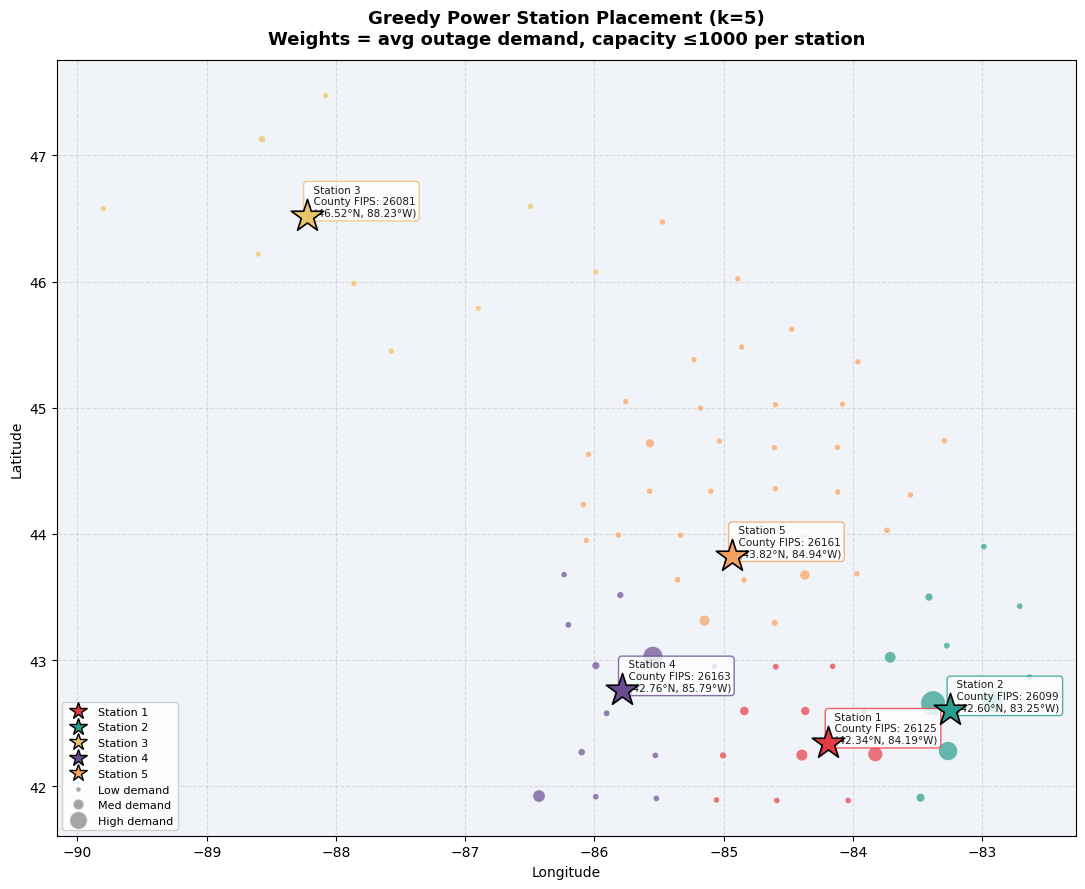

In [18]:
# ── helper: nearest county to a station center ──────────────────────────────

def nearest_county_fips(center):
    best_fips = None
    best_dist = np.inf
    for f, (lat, lon) in MICHIGAN_COORDS.items():
        d = (lat-center[0])**2 + (lon-center[1])**2
        if d < best_dist:
            best_dist = d
            best_fips = f
    return best_fips


# ── 5. Visualisation ─────────────────────────────────────────────────────────
COLORS = ["#E63946", "#2A9D8F", "#E9C46A", "#6A4C93", "#F4A261"]

fig, ax = plt.subplots(figsize=(11, 9))
ax.set_facecolor("#F0F4F8")
fig.patch.set_facecolor("#FFFFFF")

# Scatter counties, sized by weight, colored by cluster
sc = ax.scatter(
    df["lon"], df["lat"],
    c=[COLORS[l] if l >= 0 else "#BBBBBB" for l in labels],
    s=weights / weights.max() * 300 + 20,
    alpha=0.7, edgecolors="white", linewidths=0.6, zorder=3
)

# Power station markers
for j in range(K):

    county_fips = nearest_county_fips(station_coords[j])

    ax.scatter(
        centers[j, 1], centers[j, 0],
        marker="*", s=600, color=COLORS[j],
        edgecolors="black", linewidths=1.2, zorder=5
    )

    ax.annotate(
        f"  Station {j+1}\n"
        f"  County FIPS: {county_fips}\n"
        f"  ({centers[j,0]:.2f}°N, {abs(centers[j,1]):.2f}°W)",
        xy=(centers[j, 1], centers[j, 0]),
        fontsize=7.5,
        color="#1a1a1a",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            alpha=0.8,
            ec=COLORS[j],
            lw=1
        )
    )


# Legend
legend_elements = [
    Line2D([0], [0], marker="*", color="w", markerfacecolor=COLORS[j],
           markeredgecolor="black", markersize=13, label=f"Station {j+1}")
    for j in range(K)
]

legend_elements += [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
           markersize=s, alpha=0.7, label=lbl)
    for s, lbl in [(4, "Low demand"), (8, "Med demand"), (13, "High demand")]
]

ax.legend(handles=legend_elements, loc="lower left", framealpha=0.9, fontsize=8)

ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

ax.set_title(
    f"Greedy Power Station Placement (k={K})\n"
    "Weights = avg outage demand, capacity ≤1000 per station",
    fontsize=13, fontweight="bold", pad=12
)

ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("power_stations.png", dpi=150, bbox_inches="tight")

print("\nPlot saved → power_stations.png")